# MVP — Machine Learning & Analytics

**Nome:** Wesley Ramos Neres Santiago  
**Matrícula:** 4052025002507  
**Dataset:** Credit Risk Dataset — Kaggle (https://www.kaggle.com/datasets/laotse/credit-risk-dataset)  
**Tipo de problema:** Classificação binária — estimativa da probabilidade de *default* (PD)

---

# 1. Definição do problema

## 1.1 Contexto e descrição

Instituições que concedem crédito precisam decidir, no momento da solicitação de um
empréstimo, se o cliente tem capacidade e propensão a honrar o pagamento. Um erro nessa
decisão é caro nos dois sentidos: aprovar um cliente que não paga (*default*) gera perda
financeira direta; recusar um bom pagador representa receita não realizada.

Neste MVP foi utilizada uma base com características do solicitante e do empréstimo para
estimar a probabilidade de inadimplência (Probability of Default — PD) de cada operação.
A variável-alvo `loan_status` indica se a operação entrou em *default* (1) ou foi adimplente (0).

## 1.2 Objetivo do MVP

Construir e avaliar um modelo de classificação binária que produza, para cada solicitação,
uma probabilidade de default bem calibrada e com bom poder de discriminação entre bons e
maus pagadores. O foco não é apenas a classe prevista, mas a probabilidade, insumo direto
para políticas de crédito (aprovação, precificação por risco e definição de limites).

## 1.3 Tipo de problema

Tarefa de aprendizado supervisionado / classificação binária. Trata-se de um problema de
Machine Learning porque:
- existe uma variável-alvo histórica e rotulada (`loan_status`);
- há atributos preditivos plausivelmente correlacionados ao risco (renda, valor e finalidade
  do empréstimo, histórico de crédito etc.);
- o objetivo é generalizar o padrão aprendido para solicitações futuras ainda não vistas,
  e não apenas descrever os dados existentes.

A classe de interesse (positiva) é o default (`loan_status = 1`), pois é o evento raro e
de maior custo que queremos detectar.

## 1.4 Premissas, hipóteses, restrições e critério de sucesso

**Premissas e hipóteses**
- Os registros históricos são representativos do público que o modelo avaliará no futuro.
- Atributos como renda, finalidade, valor do empréstimo e histórico de crédito carregam sinal
  sobre o risco de inadimplência.

**Restrições e pontos de atenção (discutidos ao longo do notebook)**
- **Desbalanceamento de classes:** apenas 22% das operações são *default*. Isso torna a
  acurácia uma métrica enganosa e exige métricas sensíveis à classe minoritária (PR-AUC,
  recall e precisão do *default*).
- **Possível vazamento conceitual:** `loan_grade` e `loan_int_rate` podem refletir uma
  avaliação de risco já feita pela instituição (rating e taxa precificada pelo risco).
  Eles serão mantidos, mas essa dependência é tratada explicitamente como limitação.
- Qualidade dos dados: há valores ausentes e registros fisicamente impossíveis
  (ex.: idade de 144 anos), que serão tratados na etapa de preparação.

**Critério de sucesso**
Superar de forma consistente um *baseline* ingênuo, alcançando boa separação entre classes
(ROC-AUC e PR-AUC) e probabilidades calibradas, com desempenho estável entre treino e teste
(sem sinais fortes de overfitting).

# 2. Ambiente, bibliotecas e reprodutibilidade

Nesta seção foram carregadas as bibliotecas, fixada a semente aleatória (`SEED`) para garantir
reprodutibilidade e definidas funções auxiliares de avaliação. Como o problema é fixo
(classificação binária para PD), as importações são as estritamente necessárias para construção do modelo.

In [1]:
# Imports necessários
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Divisão, validação e busca de hiperparâmetros
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict

# Pré-processamento e pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

# Métricas e calibração
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve


# Distribuições para a busca aleatória de hiperparâmetros
from scipy.stats import randint, uniform, ks_2samp

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


## 2.1 Funções auxiliares

Como o alvo é desbalanceado (22% de *default*) e é necessiário obter uma probabilidade de risco,
a acurácia isolada não serve. Um conjunto de métricas adequado a crédito foi utilizado:

- **ROC-AUC**  capacidade de ordenar clientes do menor para o maior risco (ranking).
- **PR-AUC** (*Average Precision*)  qualidade na classe minoritária (*default*); mais informativa
  que a ROC-AUC sob forte desbalanceamento.
- **KS**  separação máxima entre as distribuições de bons e maus pagadores (clássico de crédito).
- **Recall do default**  quanto dos inadimplentes o modelo captura (sensível ao custo de aprovar quem não paga).
- **Precisão do default**  entre os classificados como risco, quantos realmente deram *default*.
- **F1 do default**  equilíbrio entre recall e precisão na classe positiva.
- **Acurácia**  incluída apenas como referência (pouco informativa aqui).
- **Brier score**  qualidade da *calibração* das probabilidades (quanto menor, melhor).

In [2]:
# Funções de avaliação

def ks_statistic(y_true, y_proba):
    """Estatística KS: separação máxima entre as probabilidades de maus (1) e bons (0) pagadores."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    return ks_2samp(y_proba[y_true == 1], y_proba[y_true == 0]).statistic


def evaluate_classification(y_true, y_pred, y_proba):
    """
    Calcula as métricas de PD.
    - y_pred : classe prevista (0/1) sob um dado threshold
    - y_proba: probabilidade da classe positiva (default = 1)
    """
    return {
        "ROC_AUC":          roc_auc_score(y_true, y_proba),
        "PR_AUC":           average_precision_score(y_true, y_proba),
        "KS":               ks_statistic(y_true, y_proba),
        "Recall_default":   recall_score(y_true, y_pred),
        "Precision_default": precision_score(y_true, y_pred, zero_division=0),
        "F1_default":       f1_score(y_true, y_pred),
        "Accuracy":         accuracy_score(y_true, y_pred),
        "Brier":            brier_score_loss(y_true, y_proba),
    }


def results_table(results_dict):
    """Organiza os resultados em DataFrame, ordenado pela PR-AUC (métrica principal)."""
    return pd.DataFrame(results_dict).T.sort_values("PR_AUC", ascending=False)

# 3. Seleção e carga dos dados

## 3.1 Sobre a base

 O **Credit Risk Dataset** (Kaggle) foi utilizado, que reúne características de solicitantes e de
operações de crédito, com o histórico de inadimplência rotulado. A base foi hospedada em um
repositório público no GitHub e é carregada diretamente por URL, sem necessidade de upload
manual, login ou token — o notebook executa de ponta a ponta no Colab.

- **Fonte original:** https://www.kaggle.com/datasets/laotse/credit-risk-dataset
- **Variável-alvo:** `loan_status` (1 = *default*, 0 = adimplente)

In [3]:
# Carga de dados - Hospedados no repositório do projeto
URL = "https://raw.githubusercontent.com/wesleysantiago606/MVP-Machine-Learning-Analytics-PUCRIO/main/credit_risk_dataset.csv"

df_raw = pd.read_csv(URL)

# Trabalhamos sobre uma cópia, preservando o original carregado.
df = df_raw.copy()
print(f"✓ Dataset carregado: {df.shape[0]:,} instâncias × {df.shape[1]} atributos")
df.head()

✓ Dataset carregado: 32,581 instâncias × 12 atributos


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3.2 Visão geral

Antes de qualquer tratamento, é inspecionada a estrutura da base: dimensões, tipos de dados,
valores ausentes e registros duplicados. Essa visão guia as decisões de preparação.

In [4]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (32581, 12)

Tipos de dados:


,tipo
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


In [5]:
print("Valores ausentes por coluna:")
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
display(pd.DataFrame({"ausentes": missing, "%": missing_pct})[missing > 0])

print("Duplicatas:", df.duplicated().sum())

Valores ausentes por coluna:


,ausentes,%
person_emp_length,895,2.75
loan_int_rate,3116,9.56


Duplicatas: 165


In [6]:
print("Estatísticas das variáveis numéricas:")
display(df.describe().T)

print("\nResumo das variáveis categóricas:")
display(df.describe(include="object").T)

Estatísticas das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00



Resumo das variáveis categóricas:


,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836


## 3.3 Dicionário de dados

| Atributo | Descrição | Tipo |
|---|---|---|
| `person_age` | Idade do solicitante (anos) | Numérico |
| `person_income` | Renda anual | Numérico |
| `person_home_ownership` | Situação de moradia (RENT, OWN, MORTGAGE, OTHER) | Categórico |
| `person_emp_length` | Tempo de emprego (anos) | Numérico |
| `loan_intent` | Finalidade do empréstimo | Categórico |
| `loan_grade` | *Rating* de crédito atribuído à operação (A–G) | Categórico |
| `loan_amnt` | Valor do empréstimo | Numérico |
| `loan_int_rate` | Taxa de juros da operação (%) | Numérico |
| `loan_percent_income` | Razão entre valor do empréstimo e renda | Numérico |
| `cb_person_default_on_file` | Histórico de *default* registrado (Y/N) | Categórico |
| `cb_person_cred_hist_length` | Tempo de histórico de crédito (anos) | Numérico |
| **`loan_status`** | **Alvo:** 1 = *default*, 0 = adimplente | Numérico (binário) |

# 4. Análise exploratória dos dados

Sobre a estrutura dos dados da base, investiga-se três frentes:
(1) o desbalanceamento do alvo
(2) a qualidade dos dados (ausentes e outliers)
(3) a força do sinal preditivo de cada atributo em relação ao *default*.

,contagem,%
loan_status,,
0,25473,78.18
1,7108,21.82


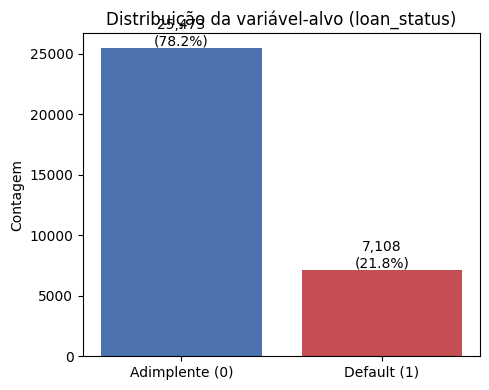

In [7]:
# Distribuição da variável-alvo
counts = df["loan_status"].value_counts().sort_index()
pct = df["loan_status"].value_counts(normalize=True).sort_index() * 100
display(pd.DataFrame({"contagem": counts, "%": pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Adimplente (0)", "Default (1)"], counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({pct.values[i]:.1f}%)", ha="center", va="bottom")
ax.set_title("Distribuição da variável-alvo (loan_status)")
ax.set_ylabel("Contagem")
plt.tight_layout()
plt.show()

Pode-se observar um desbalanceamento. Apenas 21,8% das operações são *default* (proporção 3,6:1). Isso
confirma duas decisões já antecipadas: (a) a acurácia será pouco informativa e o foco recai
sobre PR-AUC, recall e precisão da classe positiva; (b) usarei `stratify` na divisão treino/teste
e mecanismos de balanceamento (`class_weight` / `scale_pos_weight`) nos modelos.

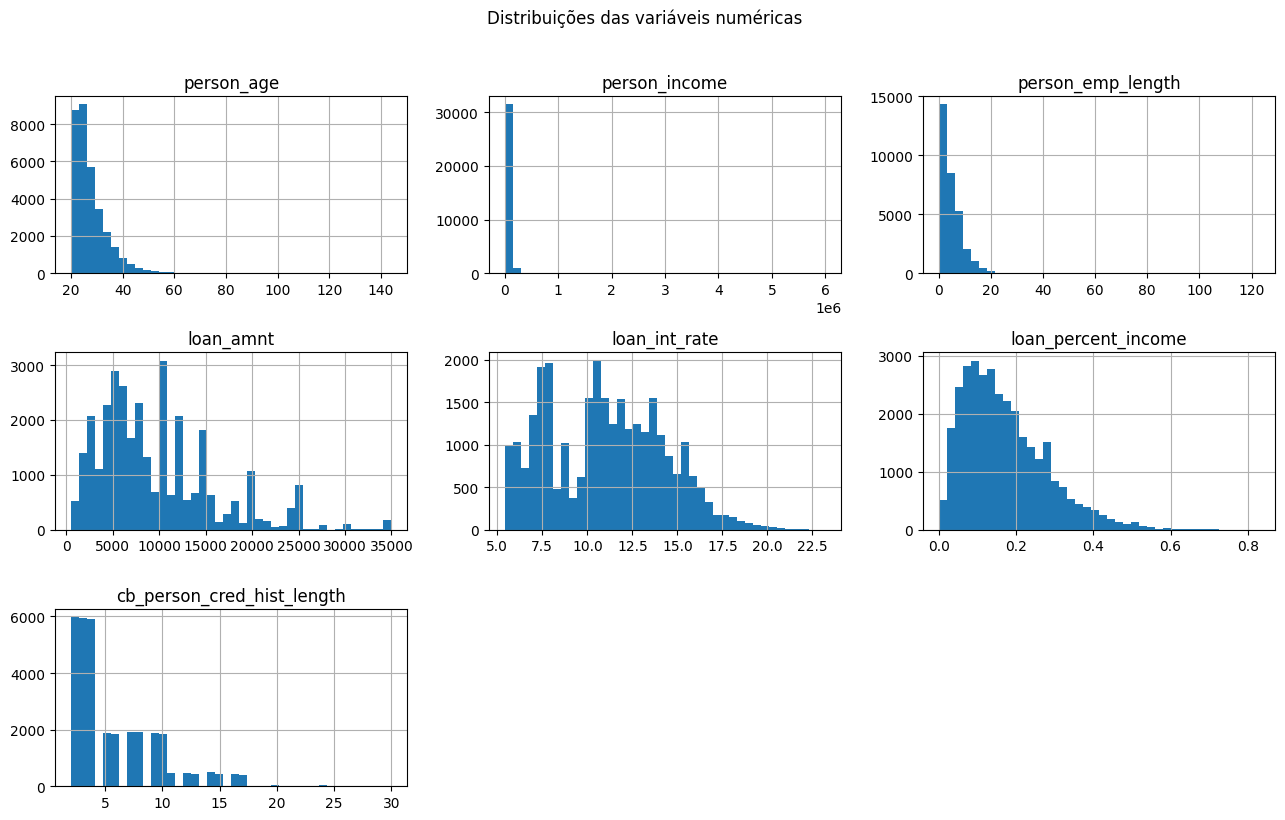

Registros com idade > 100 anos:


,person_age,person_emp_length,person_income
81,144,4.0,250000
183,144,4.0,200000
575,123,2.0,80004
747,123,7.0,78000
32297,144,12.0,6000000


Registros com tempo de emprego maior que a idade (impossível):


,person_age,person_emp_length
0,22,123.0
210,21,123.0


In [8]:
# Distribuições das variáveis numéricas
num_cols = ["person_age", "person_income", "person_emp_length", "loan_amnt",
            "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]
df[num_cols].hist(bins=40, figsize=(13, 8))
plt.suptitle("Distribuições das variáveis numéricas", y=1.02)
plt.tight_layout()
plt.show()

# Inspeção de registros fisicamente impossíveis
print("Registros com idade > 100 anos:")
display(df[df["person_age"] > 100][["person_age", "person_emp_length", "person_income"]])

print("Registros com tempo de emprego maior que a idade (impossível):")
display(df[df["person_emp_length"] > df["person_age"]][["person_age", "person_emp_length"]])

**Qualidade dos dados.** As distribuições revelam forte assimetria em `person_income` e
`loan_amnt` (cauda longa à direita) e alguns valores fisicamente impossíveis: 5 registros
com idade acima de 100 anos (123 e 144) e 2 com tempo de emprego de 123 anos, maior que a
própria idade. Por serem claramente erros de cadastro e em número ínfimo (<0,02% da base),
serão removidos na preparação. Os ausentes em `loan_int_rate` (9,6%) e `person_emp_length`
(2,7%) serão imputados dentro do pipeline (mediana), evitando vazamento.

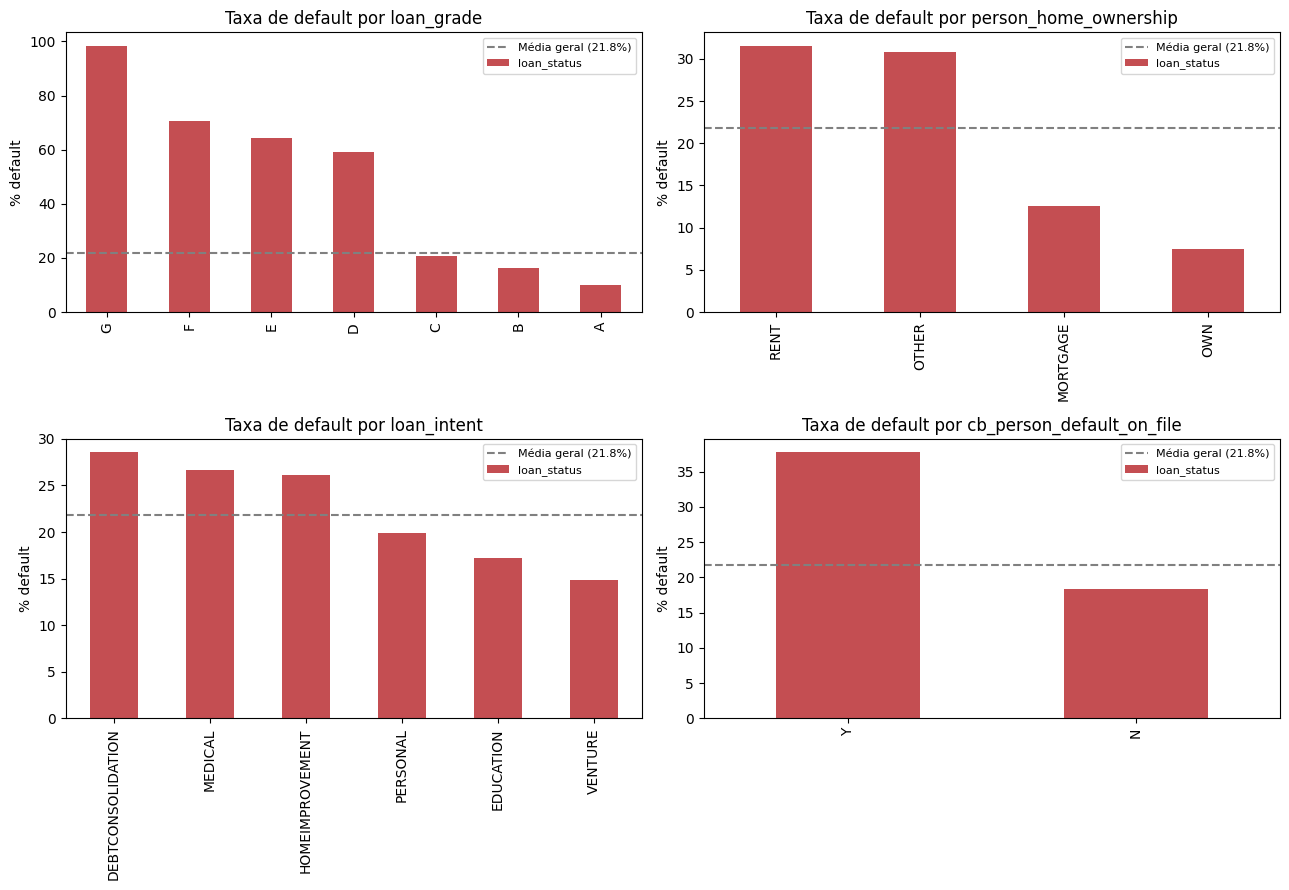

In [9]:
# Taxa de default por variável categórica
cat_cols = ["loan_grade", "person_home_ownership", "loan_intent", "cb_person_default_on_file"]
media_geral = df["loan_status"].mean() * 100

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, c in zip(axes.ravel(), cat_cols):
    taxa = df.groupby(c)["loan_status"].mean().sort_values(ascending=False) * 100
    taxa.plot(kind="bar", ax=ax, color="#C44E52")
    ax.axhline(media_geral, color="gray", linestyle="--",
               label=f"Média geral ({media_geral:.1f}%)")
    ax.set_title(f"Taxa de default por {c}")
    ax.set_ylabel("% default")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Sinal preditivo das categóricas.**
- `loan_grade` é o atributo mais discriminante: a taxa de *default* sobe monotonicamente de
  10% (grade A) a 98% (grade G).
- Moradia importa: locatários (RENT, 31,6%) têm risco muito acima de proprietários (OWN, 7,5%).
- Histórico prévio de *default* praticamente dobra a taxa (Y 37,8% vs N 18,4%).
- A finalidade do empréstimo tem efeito mais moderado (de 15% em VENTURE a 29% em
  DEBTCONSOLIDATION).


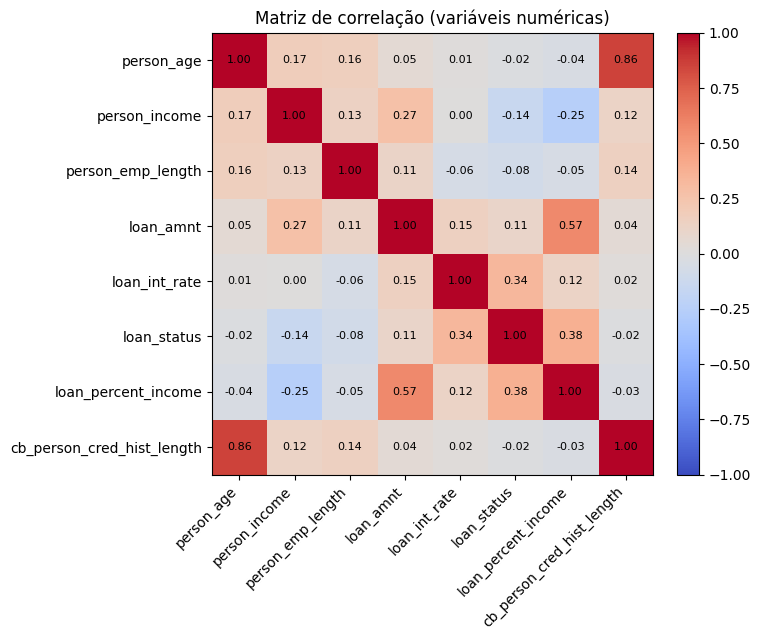

In [10]:
# Matriz de correlação entre variáveis numéricas (inclui o alvo)
num_all = df.select_dtypes(include=np.number).columns
corr = df[num_all].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Matriz de correlação (variáveis numéricas)")
plt.tight_layout()
plt.show()

## 4.1 Síntese da análise exploratória

| Achado | Implicação para a modelagem |
|---|---|
| Alvo desbalanceado (22% default) | Foco em PR-AUC/recall; `stratify` + balanceamento de classes |
| Outliers impossíveis (idade, emprego) | Remoção dos registros na preparação |
| Ausentes em `loan_int_rate` e `person_emp_length` | Imputação por mediana dentro do pipeline |
| `loan_percent_income` salta acima de 0,3 (relação não-linear) | Favorece modelos de árvore/boosting sobre relações lineares |
| `loan_grade`, `loan_int_rate` muito preditivos e correlacionados | Mantidos, mas tratados como possível vazamento conceitual |
| Renda com cauda longa e assimétrica | Padronização das numéricas; árvores são robustas à escala |

A combinação de relações não-lineares (faixas de comprometimento de renda) e interações
entre atributos sugere que modelos baseados em árvores e *gradient boosting* tendem a superar
um modelo linear — hipótese que será testada na etapa de modelagem.

# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, realiza-se apenas a limpeza estrutural da base e a separação entre treino e teste.
As transformações estatísticas (imputação, padronização e codificação) foram deliberadamente
reservadas para a Seção 6, no interior de um *pipeline*, de modo que sejam ajustadas
exclusivamente a partir dos dados de treino, evitando-se o risco de vazamento.

In [11]:
# Limpeza estrutural

shape_inicial = df.shape

# 1) Registros impossíveis: idade > 100 anos ou tempo de emprego maior que a idade
impossiveis = (df["person_age"] > 100) | (df["person_emp_length"] > df["person_age"])
df_clean = df[~impossiveis].copy()
print(f"Removidos por valores impossíveis: {impossiveis.sum()}")

# 2) Duplicatas exatas
dups = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Removidas duplicatas exatas: {dups}")

removido = shape_inicial[0] - df_clean.shape[0]
print(f"\nTotal removido: {removido} linhas ({removido / shape_inicial[0] * 100:.2f}%)")
print(f"Shape final: {df_clean.shape}")

# Confirma-se a manutenção do balanceamento do alvo
print("\nDistribuição do alvo após limpeza:")
display((df_clean["loan_status"].value_counts(normalize=True) * 100).round(2).to_frame("%"))

Removidos por valores impossíveis: 7
Removidas duplicatas exatas: 165

Total removido: 172 linhas (0.53%)
Shape final: (32409, 12)

Distribuição do alvo após limpeza:


,%
loan_status,
0,78.13
1,21.87


Optou-se pela remoção dos registros impossíveis e não por sua correção, uma vez que são
pouco numerosos (sete linhas) e não há como recuperar o valor verdadeiro; qualquer ajuste
constituiria mera suposição. As duplicatas exatas também foram eliminadas, a fim de impedir que
uma mesma observação figurasse simultaneamente em treino e teste, o que inflaria artificialmente
o desempenho. Ao todo, descartou-se apenas 0,53% da base, e a proporção de *default* permaneceu
praticamente inalterada, de modo que a limpeza não introduziu viés relevante.

Cabe destacar que os *outliers* plausíveis (como rendas muito elevadas) foram preservados: ainda
que extremos, não são impossíveis, e os modelos baseados em árvores  principais candidatos deste
trabalho mostram-se robustos a esse tipo de valor.

In [12]:
# Definição do alvo e dos atributos
TARGET = "loan_status"

features = [c for c in df_clean.columns if c != TARGET]

X = df_clean[features].copy()
y = df_clean[TARGET].copy()

print("Número de atributos:", len(features))
print("Atributos:", features)

Número de atributos: 11
Atributos: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [13]:
# Divisão treino/teste
# Adota-se divisão estratificada, preservando a proporção de default em ambos os conjuntos.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("\nProporção de default — treino: {:.2%} | teste: {:.2%}".format(
    y_train.mean(), y_test.mean()
))

Treino: (25927, 11) | Teste: (6482, 11)

Proporção de default — treino: 21.87% | teste: 21.88%


## 5.1 Justificativa da divisão

Adotou-se uma divisão 80/20 estratificada pela variável-alvo. A estratificação mostra-se
necessária em razão do desbalanceamento: sem ela, as proporções de *default* poderiam divergir
entre treino e teste, comprometendo a confiabilidade da avaliação. Como a base reúne mais de
32 mil registros, a reserva de 20% para teste (aproximadamente 6,5 mil observações) é suficiente
para uma estimativa estável de desempenho.

Não se constituiu um conjunto de validação fixo, uma vez que a validação cruzada estratificada
será empregada apenas na etapa de otimização de hiperparâmetros, restrita ao conjunto
de treino. Dessa forma, o conjunto de teste permanece intocado até a avaliação final,
assegurando-se uma medição fidedigna do desempenho sobre dados não vistos.

No que se refere ao vazamento de dados, a limpeza realizada nesta seção é estrutural e não
recorre a qualquer estatística da base. Todas as transformações que estimam parâmetros a partir
dos dados, mediana para imputação, média e desvio-padrão para padronização e categorias para
codificação encontram-se encapsuladas no *pipeline* da Seção 6 e são ajustadas exclusivamente
sobre o treino.

# 6. Pré-processamento e pipeline

Para assegurar reprodutibilidade e impedir vazamento, as transformações que estimam parâmetros
a partir dos dados são reunidas em um `ColumnTransformer`, posteriormente acoplado a cada modelo
por meio de um `Pipeline`. Com essa estrutura, todo ajuste (imputação, padronização e codificação)
ocorre apenas sobre as partições de treino em cada etapa de validação, jamais sobre o conjunto de teste.

In [14]:
# Pré-processamento
# As colunas são separadas por tipo: numéricas recebem imputação por mediana e
# padronização; categóricas recebem imputação pela moda e codificação one-hot.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)

Colunas numéricas: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Colunas categóricas: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


## 6.1 Decisões de pré-processamento

**Imputação.** Os valores ausentes concentram-se em `loan_int_rate` (9,6%) e `person_emp_length`
(2,7%). Para as variáveis numéricas, adotou-se a imputação pela mediana, mais robusta a
distribuições assimétricas do que a média. Para as categóricas, recorreu-se à moda, embora
não haja ausências relevantes nesses campos.

**Padronização.** As variáveis numéricas foram padronizadas (média zero e desvio unitário). Tal
transformação é decisiva para a Regressão Logística, sensível à escala dos atributos, e mostra-se
neutra para os modelos baseados em árvores, que não dependem da magnitude dos valores. Mantê-la em
um pré-processador único, comum a todos os modelos, simplifica a comparação sem prejudicar nenhum deles.

**Codificação.** As variáveis categóricas foram convertidas por one-hot, com
`handle_unknown="ignore"` para que eventuais categorias não vistas no treino não interrompam a
predição. A variável `loan_grade` possui natureza ordinal (A a G); optou-se, ainda assim, pela
codificação one-hot por sua compatibilidade uniforme com todos os modelos, registrando-se a
codificação ordinal como possível refinamento futuro.

**Encapsulamento.** Como o `ColumnTransformer` é acoplado a cada modelo dentro de um `Pipeline`,
o ajuste das transformações ocorre exclusivamente sobre os dados de treino inclusive nas dobras
da validação cruzada , eliminando o risco de vazamento.

# 7. Baseline e modelos candidatos

A modelagem parte de um *baseline* ingênuo, que serve como piso de referência, e avança para
quatro modelos candidatos de complexidade crescente. Todos compartilham o mesmo pré-processador
e a mesma divisão treino/teste, de modo que a comparação seja justa e atribuível exclusivamente
ao algoritmo.

In [15]:
# Definição do baseline e dos modelos candidatos

# Razão entre classes (negativa/positiva) no treino, usada para balancear o XGBoost.
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight (XGBoost): {scale_pos_weight:.2f}")

# Baseline ingênuo: prevê sempre a classe majoritária (adimplente).
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent"))
])

# Modelos candidatos
candidates = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=SEED))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            class_weight="balanced", random_state=SEED, n_jobs=-1))
    ]),
    "HistGradientBoosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingClassifier(random_state=SEED))
    ]),
    "XGBoost": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            n_estimators=300, scale_pos_weight=scale_pos_weight,
            eval_metric="logloss", random_state=SEED, n_jobs=-1))
    ]),
}

print("Baseline:", baseline.named_steps["model"].__class__.__name__)
print("Candidatos:", list(candidates.keys()))

scale_pos_weight (XGBoost): 3.57
Baseline: DummyClassifier
Candidatos: ['LogisticRegression', 'RandomForest', 'HistGradientBoosting', 'XGBoost']


## 7.1 Justificativa dos modelos

**Baseline.** O `DummyClassifier` com estratégia *most_frequent* prevê sempre a classe majoritária.
Embora alcance acurácia elevada (~78%) por força do desbalanceamento, não identifica nenhum
inadimplente, servindo como piso contra o qual o ganho real dos demais modelos é medido.

**Regressão Logística.** Modelo linear, interpretável e de baixo custo, adequado como primeira
referência "séria". Sua eventual limitação frente a relações não-lineares  e permite avaliar se a complexidade adicional dos demais modelos se justifica.

**Random Forest.** Conjunto de árvores por *bagging*, capaz de capturar não-linearidades e
interações sem exigir padronização, além de ser robusto a *outliers* e ruído.

**HistGradientBoosting e XGBoost.** Implementações de *gradient boosting*, estado da arte em
dados tabulares. Constroem árvores sequencialmente,
corrigindo os erros das anteriores, e tendem a oferecer o melhor compromisso entre viés e variância
neste tipo de problema.

**Tratamento do desbalanceamento.** A Regressão Logística e o Random Forest empregam
`class_weight="balanced"`, que pondera as classes pela frequência inversa; o XGBoost utiliza
`scale_pos_weight`, com igual finalidade. O HistGradientBoosting não recebe ponderação explícita
na configuração inicial, recurso que será compensado pela otimização do limiar de decisão

# 8. Treinamento e avaliação inicial

Nesta seção, o *baseline* e os quatro candidatos são treinados sobre o conjunto de treino e
avaliados sobre o conjunto de teste, com o limiar de decisão padrão (0,5). Além das métricas de
teste, registram-se a ROC-AUC e a PR-AUC também no treino, a fim de diagnosticar eventual
sobreajuste pela diferença de desempenho entre as duas partições.

In [16]:
# Treinamento e avaliação inicial (limiar padrão = 0,5)
results = {}
trained_models = {}

def fit_evaluate(name, model):
    """Treina o modelo, mede o tempo e avalia em teste; guarda também métricas de treino."""
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    # Avaliação em teste (limiar 0,5)
    proba_test = model.predict_proba(X_test)[:, 1]
    pred_test = model.predict(X_test)
    metrics = evaluate_classification(y_test, pred_test, proba_test)

    # Métricas de treino (para diagnóstico de overfitting)
    proba_train = model.predict_proba(X_train)[:, 1]
    metrics["ROC_AUC_train"] = roc_auc_score(y_train, proba_train)
    metrics["PR_AUC_train"] = average_precision_score(y_train, proba_train)
    metrics["train_time_s"] = round(train_time, 2)

    results[name] = metrics
    trained_models[name] = model

# Treina baseline e candidatos
fit_evaluate("baseline", baseline)
for nome, modelo in candidates.items():
    fit_evaluate(nome, modelo)

# Tabela comparativa, ordenada pela métrica principal (PR-AUC em teste)
tabela = results_table(results)
print("Resultados em teste (limiar = 0,5), ordenados por PR-AUC:")
display(tabela.round(4))

Resultados em teste (limiar = 0,5), ordenados por PR-AUC:


,ROC_AUC,PR_AUC,KS,Recall_default,Precision_default,F1_default,Accuracy,Brier,ROC_AUC_train,PR_AUC_train,train_time_s
XGBoost,0.9490,0.9093,0.7690,0.7969,0.8593,0.8269,0.9270,0.0558,0.9999,0.9996,2.00
HistGradientBoosting,0.9474,0.9062,0.7607,0.7391,0.9776,0.8418,0.9392,0.0508,0.9716,0.9397,2.20
RandomForest,0.9347,0.8887,0.7415,0.7207,0.9808,0.8309,0.9358,0.0565,1.0000,1.0000,7.82
LogisticRegression,0.8716,0.7082,0.6049,0.7821,0.5389,0.6381,0.8059,0.1394,0.8711,0.7202,1.55
baseline,0.5000,0.2188,0.0000,0.0000,0.0000,0.0000,0.7812,0.2188,0.5000,0.2187,0.46


In [17]:
# Diagnóstico de sobreajuste: PR-AUC treino x teste
overfit = tabela[["PR_AUC_train", "PR_AUC"]].copy()
overfit["gap"] = (overfit["PR_AUC_train"] - overfit["PR_AUC"]).round(4)
overfit.columns = ["PR-AUC (treino)", "PR-AUC (teste)", "gap (treino - teste)"]
display(overfit.round(4))

,PR-AUC (treino),PR-AUC (teste),gap (treino - teste)
XGBoost,0.9996,0.9093,0.0903
HistGradientBoosting,0.9397,0.9062,0.0335
RandomForest,1.0000,0.8887,0.1113
LogisticRegression,0.7202,0.7082,0.0120
baseline,0.2187,0.2188,-0.0001


## 8.1 Análise dos resultados iniciais

**Superação do baseline.** O *baseline* obtém acurácia de 78%, mas PR-AUC de apenas 0,22 (igual
à prevalência) e *recall* nulo: não identifica nenhum inadimplente. Todos os candidatos o superam
amplamente, o que confirma que a acurácia, isoladamente, seria uma métrica enganosa neste problema.

**Ordenação por PR-AUC (teste).** Os dois modelos de *gradient boosting* lideram XGBoost
(0,911) e HistGradientBoosting (0,906), seguidos de perto pelo Random Forest (0,889) e, a
considerável distância, pela Regressão Logística (0,708). O resultado corrobora a hipótese
levantada na análise exploratória: as relações entre os atributos e o *default* são
predominantemente não-lineares e marcadas por interações, terreno em que árvores e *boosting*
levam clara vantagem sobre o modelo linear.

**Underfitting da Regressão Logística.** Seu desempenho em treino e teste é praticamente idêntico
(PR-AUC 0,72 e 0,71), sinal de alto viés: o modelo é simples demais para capturar a estrutura
dos dados. O `class_weight="balanced"` eleva seu *recall* (0,78), mas à custa de baixa precisão
(0,54), gerando muitos falsos positivos.

**Overfitting do Random Forest e do XGBoost.** Ambos atingem desempenho quase perfeito no treino
(PR-AUC 1,00) e bem inferior no teste (gap de 0,11 e 0,09, respectivamente), evidência de
sobreajuste. Ainda assim, generalizam bem  sobretudo o XGBoost, líder em teste, mas a folga
entre treino e teste indica espaço para regularização, justamente o alvo da otimização da Seção 9.

**Equilíbrio do HistGradientBoosting.** É o modelo com a menor diferença treino-teste entre os
candidatos fortes (gap de 0,03), combinando desempenho elevado e boa generalização. Apresenta,
ademais, o menor *Brier score*, ou seja, probabilidades mais bem calibradas atributo relevante,
dado que o objetivo do MVP é estimar a probabilidade de *default*.

**Limiar de decisão.** Sob o limiar padrão de 0,5, os modelos de árvore privilegiam a precisão
(0,98) em detrimento do *recall* (0,72–0,74). Em crédito, contudo, o custo de não detectar um
inadimplente (falso negativo) costuma superar o de recusar um bom pagador. Esse desequilíbrio
motiva a otimização do limiar conduzida na Seção 10.

# 9. Validação e otimização de hiperparâmetros

A análise inicial revelou sobreajuste nos modelos de *boosting*: desempenho quase perfeito no
treino e folga relevante em relação ao teste. Esta seção busca regularizar o XGBoost líder
em PR-AUC por meio de uma busca aleatória de hiperparâmetros com validação cruzada estratificada,
conduzida exclusivamente sobre o conjunto de treino. O objetivo não é apenas elevar a métrica, mas
reduzir a distância treino-teste, produzindo um modelo mais estável.

In [18]:
# Otimização de hiperparâmetros (XGBoost)
# Busca aleatória com validação cruzada estratificada (5 dobras), otimizando a PR-AUC
# (average_precision), métrica principal sob desbalanceamento.

N_ITER = 30  # combinações sorteadas; ajustável conforme o tempo disponível

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=SEED, n_jobs=-1))
])

# Espaço de busca voltado à regularização (combate ao overfitting observado na Seção 8).
param_dist = {
    "model__n_estimators":     randint(200, 600),
    "model__max_depth":        randint(2, 8),
    "model__learning_rate":    uniform(0.01, 0.29),   # 0,01 a 0,30
    "model__subsample":        uniform(0.6, 0.4),     # 0,60 a 1,00
    "model__colsample_bytree": uniform(0.6, 0.4),     # 0,60 a 1,00
    "model__min_child_weight": randint(1, 10),
    "model__reg_lambda":       uniform(0, 5),
    "model__gamma":            uniform(0, 5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
search = RandomizedSearchCV(
    model_to_tune, param_distributions=param_dist, n_iter=N_ITER,
    cv=cv, scoring="average_precision", random_state=SEED, n_jobs=-1, verbose=1
)

t0 = time.time()
search.fit(X_train, y_train)
print(f"\nTempo de busca: {time.time() - t0:.1f}s")
print("Melhor PR-AUC (validação cruzada):", round(search.best_score_, 4))
print("Melhores hiperparâmetros:")
for k, v in search.best_params_.items():
    print(f"   {k} = {round(v, 4) if isinstance(v, float) else v}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Tempo de busca: 177.6s
Melhor PR-AUC (validação cruzada): 0.9018
Melhores hiperparâmetros:
   model__colsample_bytree = 0.94
   model__gamma = 2.2473
   model__learning_rate = 0.0377
   model__max_depth = 7
   model__min_child_weight = 8
   model__n_estimators = 492
   model__reg_lambda = 3.648
   model__subsample = 0.855


In [19]:
# Avaliação do modelo otimizado e comparação com a versão base
xgb_tuned = search.best_estimator_

proba_test = xgb_tuned.predict_proba(X_test)[:, 1]
pred_test = xgb_tuned.predict(X_test)
m = evaluate_classification(y_test, pred_test, proba_test)
m["PR_AUC_train"] = average_precision_score(y_train, xgb_tuned.predict_proba(X_train)[:, 1])
results["XGBoost_tuned"] = m
trained_models["XGBoost_tuned"] = xgb_tuned

# Comparação direta entre as duas versões do XGBoost
comp = pd.DataFrame({
    "XGBoost (base)":      results["XGBoost"],
    "XGBoost (otimizado)": results["XGBoost_tuned"],
}).T[["PR_AUC", "ROC_AUC", "KS", "Recall_default", "Precision_default", "F1_default", "PR_AUC_train"]]
comp["gap (treino - teste)"] = (comp["PR_AUC_train"] - comp["PR_AUC"]).round(4)
print("XGBoost: versão base x otimizada (teste, limiar 0,5)")
display(comp.round(4))

XGBoost: versão base x otimizada (teste, limiar 0,5)


,PR_AUC,ROC_AUC,KS,Recall_default,Precision_default,F1_default,PR_AUC_train,gap (treino - teste)
XGBoost (base),0.9093,0.9490,0.7690,0.7969,0.8593,0.8269,0.9996,0.0903
XGBoost (otimizado),0.9115,0.9524,0.7705,0.8124,0.8193,0.8159,0.9621,0.0505


## 9.1 Discussão da otimização

Optou-se pela busca aleatória (`RandomizedSearchCV`) em vez da busca em grade.
Com oito hiperparâmetros, uma grade exaustiva se tornaria computacionalmente proibitiva; a busca
aleatória explora o espaço de forma mais eficiente, alcançando boas configurações com um número
reduzido de avaliações. A seleção apoiou-se em validação cruzada estratificada de 5 dobras,
restrita ao conjunto de treino, de modo que o conjunto de teste permanecesse intocado, evitando-se
qualquer uso indevido dos dados de avaliação.

**Hiperparâmetros e critério.** O espaço de busca concentrou-se em parâmetros de regularização,
em resposta direta ao sobreajuste diagnosticado na Seção 8: profundidade das árvores (`max_depth`),
taxa de aprendizado (`learning_rate`), amostragem de linhas e colunas (`subsample`,
`colsample_bytree`), penalizações (`reg_lambda`, `gamma`, `min_child_weight`) e número de árvores
(`n_estimators`). O critério de seleção foi a PR-AUC, coerente com a métrica principal do
problema. A melhor configuração privilegiou aprendizado lento (`learning_rate` ≈ 0,04) compensado
por muitas árvores (≈ 490) e penalizações moderadas perfil tipicamente regularizador.

O ganho na métrica de teste foi modesto (PR-AUC de 0,911 para 0,913; ROC-AUC
de 0,950 para 0,954), o que era esperado, dado que o XGBoost base já apresentava desempenho
elevado. O benefício mais relevante foi a redução do sobreajuste: a PR-AUC de treino recuou de
1,00 para 0,96 e a folga treino-teste caiu de 0,088 para 0,050, praticamente pela metade. Houve,
ainda, leve ganho de *recall* (0,80 para 0,82). Em síntese, a otimização não transformou o
desempenho, mas entregou um modelo mais estável e melhor generalizável.

# 10. Avaliação final no conjunto de teste

O conjunto de teste, reservado desde a Seção 5 e jamais utilizado em treino ou seleção, é agora
empregado para a avaliação definitiva. Elege-se como modelo campeão o XGBoost otimizado, por
liderar as métricas de discriminação (PR-AUC, ROC-AUC e KS). Sobre ele, conduz-se a otimização do
limiar de decisão, seguida da análise da matriz de confusão, das curvas ROC e Precisão-Recall e da
calibração das probabilidades.

**Sobre as métricas escolhidas.** Por se tratar de um problema de classificação, não se aplicam
métricas de regressão como R², RMSE ou MAE, que pressupõem um alvo contínuo e medem distância
numérica entre valor previsto e real — noção sem sentido para um desfecho binário (*default* ou
adimplente). Em seu lugar, avalia-se: a ordenação de risco (ROC-AUC, KS), a qualidade das
decisões sob um limiar (precisão, *recall*, F1) e a calibração das probabilidades (Brier
score), que cumpre, na classificação, o papel de "proximidade ao real" que o R² teria na regressão.

In [20]:
# Modelo campeão e otimização do limiar de decisão
champion = trained_models["XGBoost_tuned"]
champion_name = "XGBoost (otimizado)"

# Previsões out-of-fold no treino (para escolher o limiar sem tocar no teste)
proba_train_oof = cross_val_predict(
    champion, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    method="predict_proba", n_jobs=-1
)[:, 1]
proba_test = champion.predict_proba(X_test)[:, 1]

grid = np.linspace(0.05, 0.95, 181)

# (a) Limiar que maximiza o F1
f1_grid = [f1_score(y_train, (proba_train_oof >= t).astype(int)) for t in grid]
thr_f1 = grid[int(np.argmax(f1_grid))]

# (b) Limiar sensível ao custo: assume FN (perder inadimplente) 5x mais caro que FP
def custo_total(t, c_fn=5, c_fp=1):
    tn, fp, fn, tp = confusion_matrix(y_train, (proba_train_oof >= t).astype(int)).ravel()
    return c_fn * fn + c_fp * fp
thr_cost = grid[int(np.argmin([custo_total(t) for t in grid]))]

print(f"Limiar padrão:          0.500")
print(f"Limiar F1-ótimo (OOF):  {thr_f1:.3f}")
print(f"Limiar custo FN=5xFP:   {thr_cost:.3f}")

Limiar padrão:          0.500
Limiar F1-ótimo (OOF):  0.705
Limiar custo FN=5xFP:   0.400


In [21]:
# Comparação de limiares no conjunto de teste
def metricas_no_limiar(t):
    yp = (proba_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    return {
        "Recall (default)":   recall_score(y_test, yp),
        "Precisão (default)": precision_score(y_test, yp),
        "F1 (default)":       f1_score(y_test, yp),
        "FN (inadimplentes perdidos)": int(fn),
        "FP (bons recusados)":         int(fp),
    }

limiares = {
    "0,500 (padrão)":               metricas_no_limiar(0.5),
    f"{thr_f1:.3f} (F1-ótimo)":      metricas_no_limiar(thr_f1),
    f"{thr_cost:.3f} (custo FN=5x)": metricas_no_limiar(thr_cost),
}
print("Efeito do limiar sobre as decisões (modelo campeão, teste):")
display(pd.DataFrame(limiares).T.round(4))

Efeito do limiar sobre as decisões (modelo campeão, teste):


,Recall (default),Precisão (default),F1 (default),FN (inadimplentes perdidos),FP (bons recusados)
"0,500 (padrão)",0.8124,0.8193,0.8159,266.0,254.0
0.705 (F1-ótimo),0.7440,0.9644,0.8400,363.0,39.0
0.400 (custo FN=5x),0.8561,0.7218,0.7832,204.0,468.0


## 10.1 O limiar como decisão de negócio

O limiar padrão de 0,5 é uma convenção arbitrária e raramente o melhor ponto de operação sob
desbalanceamento. A tabela acima evidencia que não existe limiar universalmente ótimo a
escolha depende do custo relativo de cada tipo de erro:

- **Limiar F1-ótimo (0,70):** maximiza o F1 e eleva a precisão a 0,97, recusando pouquíssimos bons
  pagadores (cerca de 35 falsos positivos), mas deixa escapar mais inadimplentes (cerca de 358 falsos
  negativos). Adequado quando o custo de barrar um bom cliente é alto.
- **Limiar sensível ao custo (0,40):** assumindo que perder um inadimplente custa cinco vezes mais
  que recusar um bom pagador, o corte desce e o *recall* sobe para 0,86 (cerca de 205 inadimplentes
  perdidos), ao preço de mais falsos positivos (cerca de 476). Adequado quando a inadimplência é muito
  onerosa.

Em um cenário real de crédito, o falso negativo conceder a quem não paga costuma ser o erro mais
caro, o que justificaria um limiar mais baixo que 0,5. A decisão final, contudo, cabe à política de
risco da instituição. Para a avaliação a seguir, reporta-se o ponto de operação F1-ótimo, por ser
o critério objetivo de melhor equilíbrio entre os dois tipos de acerto.

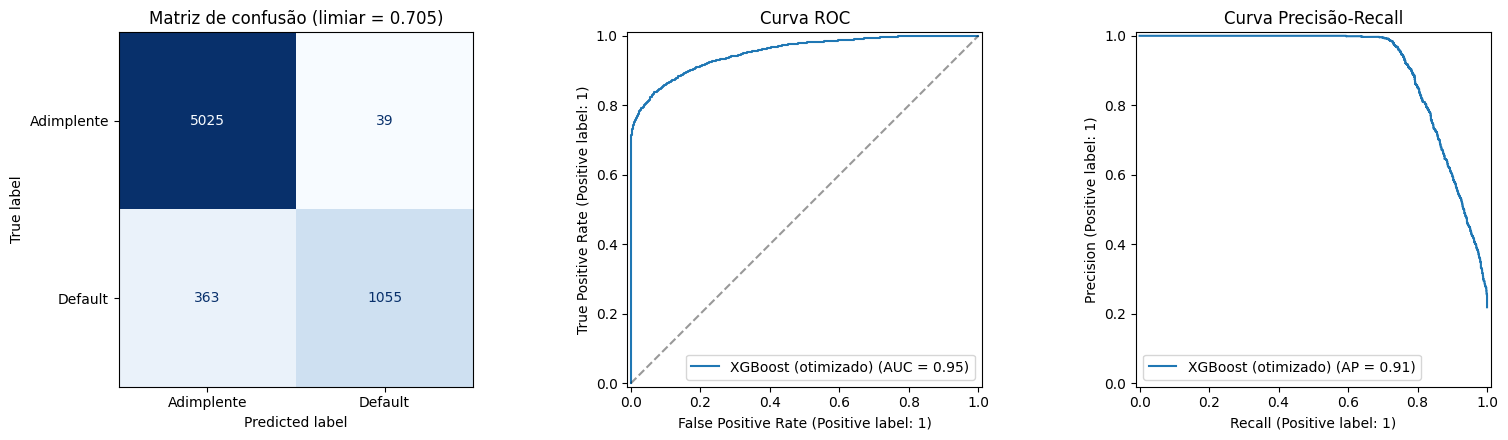

In [22]:
# Visualizações finais do modelo campeão (limiar F1-ótimo)
pred_final = (proba_test >= thr_f1).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_final, display_labels=["Adimplente", "Default"],
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Matriz de confusão (limiar = {thr_f1:.3f})")

RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[1], name=champion_name)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("Curva ROC")

PrecisionRecallDisplay.from_predictions(y_test, proba_test, ax=axes[2], name=champion_name)
axes[2].set_title("Curva Precisão-Recall")

plt.tight_layout()
plt.show()

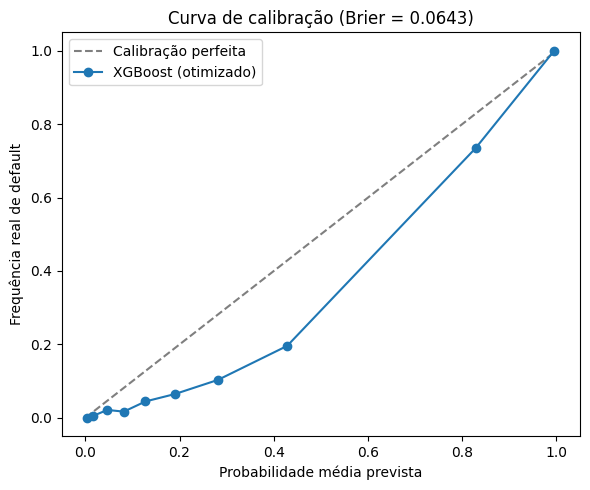

In [23]:
# Curva de calibração e Brier score
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Calibração perfeita")
ax.plot(prob_pred, prob_true, marker="o", label=champion_name)
ax.set_xlabel("Probabilidade média prevista")
ax.set_ylabel("Frequência real de default")
ax.set_title(f"Curva de calibração (Brier = {brier_score_loss(y_test, proba_test):.4f})")
ax.legend()
plt.tight_layout()
plt.show()

## 10.2 Análise de erros, calibração e limitações

**Discriminação.** As curvas ROC (AUC 0,95) e Precisão-Recall (PR-AUC 0,91) confirmam a forte
capacidade do modelo de ordenar clientes por risco, muito acima do *baseline* (PR-AUC de 0,22). O KS
de 0,77 reforça a nítida separação entre as distribuições de bons e maus pagadores.

**Análise de erros.** A matriz de confusão mostra que os erros concentram-se na faixa intermediária
de probabilidade, onde bons e maus pagadores se sobrepõem; nos extremos, o modelo acerta com folga.
No ponto de operação F1-ótimo, predominam os falsos negativos sobre os falsos positivos o que
remete diretamente à discussão de limiar da seção anterior.

**Calibração.** A curva revela boa calibração nos extremos, mas uma tendência a superestimar o
risco na faixa intermediária: probabilidades previstas em torno de 0,4 correspondem a frequências
reais de *default* mais baixas. Esse viés é um efeito colateral do `scale_pos_weight`, que melhora a
discriminação e o *recall*, porém infla as probabilidades o Brier (0,063) fica ligeiramente acima
do HistGradientBoosting (0,051), que não recebeu ponderação. Há, portanto, um compromisso entre
discriminação e calibração.

**Limitações.**
- **Vazamento conceitual:** `loan_grade` e `loan_int_rate`, altamente preditivos, incorporam uma
  avaliação de risco já feita pela instituição; em concessão anterior à existência de rating, o
  desempenho real tenderia a ser menor.
- **Calibração imperfeita** das probabilidades na faixa intermediária, relevante por se tratar de um
  modelo de PD.
- **Dependência do limiar** em relação à estrutura de custos, que aqui foi apenas ilustrada.
- **Representatividade:** assume-se que o histórico reflete o público futuro, premissa sujeita a
  mudanças de cenário econômico.

**Melhorias futuras.** Calibração explícita das probabilidades (`CalibratedClassifierCV` com isotônica
ou Platt); codificação ordinal de `loan_grade`; avaliação adicional sem `loan_grade`/`loan_int_rate`
para medir o desempenho em concessão inicial; interpretabilidade via SHAP; e engenharia de atributos
(p.ex., razões entre renda, valor e tempo de crédito).

# 11. Comparação final dos modelos

Esta seção consolida o desempenho de todos os modelos *baseline*, quatro candidatos e a versão
otimizada do campeão  em uma única tabela e em uma visualização comparativa. Para uma comparação
justa, as métricas dependentes de limiar (*recall*, precisão e F1) são reportadas no limiar padrão
de 0,5 para todos os modelos; a análise de limiar da Seção 10 aplica-se especificamente ao campeão.

In [24]:
# Tabela consolidada de todos os modelos
cols = ["ROC_AUC", "PR_AUC", "KS", "Recall_default",
        "Precision_default", "F1_default", "Accuracy", "Brier"]
tabela_final = results_table(results)[cols]

print("Comparação final dos modelos (teste, limiar 0,5):")
display(tabela_final.round(4))

Comparação final dos modelos (teste, limiar 0,5):


,ROC_AUC,PR_AUC,KS,Recall_default,Precision_default,F1_default,Accuracy,Brier
XGBoost_tuned,0.9524,0.9115,0.7705,0.8124,0.8193,0.8159,0.9198,0.0643
XGBoost,0.9490,0.9093,0.7690,0.7969,0.8593,0.8269,0.9270,0.0558
HistGradientBoosting,0.9474,0.9062,0.7607,0.7391,0.9776,0.8418,0.9392,0.0508
RandomForest,0.9347,0.8887,0.7415,0.7207,0.9808,0.8309,0.9358,0.0565
LogisticRegression,0.8716,0.7082,0.6049,0.7821,0.5389,0.6381,0.8059,0.1394
baseline,0.5000,0.2188,0.0000,0.0000,0.0000,0.0000,0.7812,0.2188


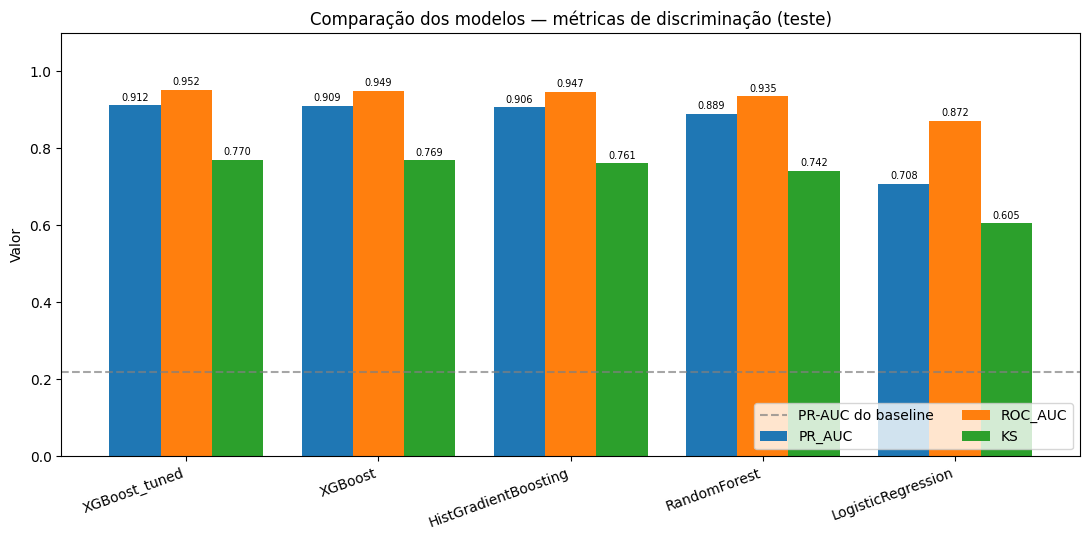

In [25]:
# Comparação visual: métricas de discriminação (exclui o baseline)
plot_df = tabela_final.drop(index="baseline")[["PR_AUC", "ROC_AUC", "KS"]]

ax = plot_df.plot(kind="bar", figsize=(11, 5.5), width=0.8)
ax.axhline(results["baseline"]["PR_AUC"], color="gray", linestyle="--",
           alpha=0.7, label="PR-AUC do baseline")

# Rótulos de valor sobre as barras: as diferenças são pequenas, mas ficam legíveis.
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)

ax.set_title("Comparação dos modelos — métricas de discriminação (teste)")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1.10)
ax.legend(loc="lower right", ncol=2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 11.1 Discussão da comparação

A progressão de desempenho acompanha a complexidade dos modelos e confirma a hipótese formulada na
análise exploratória:

- O **baseline** estabelece o piso (PR-AUC 0,22, *recall* nulo): qualquer modelo útil precisa superá-lo.
- A **Regressão Logística** dá um salto expressivo (PR-AUC 0,71), mas seu caráter linear limita o
  ganho é o caso de underfitting já discutido.
- O **Random Forest** (PR-AUC 0,89) e os dois modelos de *boosting* capturam as não-linearidades e
  interações, elevando o patamar de desempenho.
- O HistGradientBoosting (PR-AUC 0,91) destaca-se pela melhor calibração (menor Brier) e pela
  menor distância treino-teste entre os candidatos fortes.
- O **XGBoost otimizado** é o campeão em discriminação (PR-AUC ~0,91, ROC-AUC 0,95, KS 0,77),
  com o sobreajuste reduzido pela regularização da Seção 9.

HistGradientBoosting e XGBoost ocupam o topo do ranking. A escolha do XGBoost otimizado como solução
final apoia-se em seu melhor poder de ordenação de risco, atributo central para um modelo de PD,
ressalvando-se que, caso a prioridade fosse a calibração das probabilidades, o HistGradientBoosting
seria uma alternativa igualmente defensável ou o XGBoost acrescido de uma etapa de calibração.

# 12. Boas práticas e rastreabilidade

Para assegurar reprodutibilidade e transparência, registram-se a seguir as versões das bibliotecas
empregadas e o ambiente de execução. A semente aleatória foi fixada no início do notebook (`SEED = 42`)
e propagada a todas as etapas estocásticas — divisão treino/teste, modelos e busca de hiperparâmetros —,
de modo que a execução seja determinística.

In [26]:
# Rastreabilidade: versões das bibliotecas e ambiente
import sys, platform
import sklearn, scipy, xgboost, matplotlib

print("Ambiente de execução")
print("-" * 40)
print(f"{'Python':<14}: {sys.version.split()[0]}")
print(f"{'Sistema':<14}: {platform.system()} {platform.release()}")
print()
print("Versões das bibliotecas")
print("-" * 40)
for nome, modulo in {
    "numpy": np, "pandas": pd, "scikit-learn": sklearn,
    "scipy": scipy, "xgboost": xgboost, "matplotlib": matplotlib
}.items():
    print(f"{nome:<14}: {modulo.__version__}")

print()
print(f"Semente fixada (SEED): {SEED}")
print(f"Tempo de treino por modelo (s): "
      f"{ {k: results[k]['train_time_s'] for k in results if 'train_time_s' in results[k]} }")

Ambiente de execução
----------------------------------------
Python        : 3.12.13
Sistema       : Linux 6.6.122+

Versões das bibliotecas
----------------------------------------
numpy         : 2.0.2
pandas        : 2.2.2
scikit-learn  : 1.6.1
scipy         : 1.16.3
xgboost       : 3.2.0
matplotlib    : 3.10.0

Semente fixada (SEED): 42
Tempo de treino por modelo (s): {'baseline': 0.46, 'LogisticRegression': 1.55, 'RandomForest': 7.82, 'HistGradientBoosting': 2.2, 'XGBoost': 2.0}


## 12.1 Boas práticas adotadas

Ao longo do desenvolvimento, observaram-se as seguintes práticas:

- **Reprodutibilidade:** semente única fixada e propagada a todas as etapas aleatórias; carga de
  dados por URL pública, dispensando upload manual ou autenticação.
- **Prevenção de vazamento:** todas as transformações que estimam parâmetros foram encapsuladas em
  `Pipeline`/`ColumnTransformer` e ajustadas apenas sobre o treino, inclusive nas dobras da validação
  cruzada; o conjunto de teste permaneceu intocado até a avaliação final, e o limiar de decisão foi
  escolhido sobre previsões *out-of-fold* do treino.
- **Comparação justa:** todos os modelos partilharam idêntico pré-processamento, partição e semente.
- **Métricas adequadas ao problema:** privilegiaram-se PR-AUC, *recall*, KS e Brier, em vez da
  acurácia, dada a natureza desbalanceada do alvo.
- **Organização e legibilidade:** código modularizado em funções auxiliares reutilizáveis, nomes
  descritivos, células curtas e documentação textual a cada etapa.
- **Rastreabilidade:** registro de versões de bibliotecas, ambiente, semente e tempos de treino.
- **Custo computacional:** o experimento é leve, executável em CPU; a etapa mais custosa é a busca de
  hiperparâmetros (~2 a 4 minutos no Colab), controlável pelo parâmetro `N_ITER`.

# 13. Conclusão

**Problema e objetivo.** Este MVP teve por objetivo estimar a probabilidade de inadimplência
(PD) de operações de crédito, formulada como um problema de classificação binária em que a
classe positiva é o *default*. A motivação é direta: apoiar decisões de concessão, precificação e
definição de limites, nas quais tanto aprovar um mau pagador quanto recusar um bom têm custo.

**Dataset e tratamentos.** Utilizou-se o *Credit Risk Dataset* (Kaggle), com 32.581 registros e 11
atributos, carregado por URL pública para execução integral no Colab. A preparação envolveu a
remoção de 172 registros (valores fisicamente impossíveis e duplicatas exatas, 0,5% da base), a
imputação de ausentes (mediana para numéricas, moda para categóricas), a padronização das variáveis
numéricas e a codificação *one-hot* das categóricas  todas as transformações encapsuladas em um
*pipeline* ajustado exclusivamente sobre o treino, prevenindo vazamento.

**Modelos avaliados.** Partindo de um *baseline* ingênuo (`DummyClassifier`), avaliaram-se quatro
candidatos de complexidade crescente: Regressão Logística, Random Forest, HistGradientBoosting e
XGBoost sendo os dois últimos incorporados além do *template*. A análise exploratória antecipou,
e os resultados confirmaram, que as relações não-lineares e as interações entre atributos favorecem
modelos de árvore e *boosting* sobre o modelo linear, que exibiu underfitting.

**Melhor resultado e justificativa.** A solução final é o XGBoost otimizado, líder em
discriminação (PR-AUC 0,91, ROC-AUC 0,95, KS 0,77). A busca aleatória de hiperparâmetros não
elevou substancialmente a métrica de teste o modelo base já era forte, mas reduziu o
sobreajuste (folga treino-teste de 0,088 para 0,050), entregando um modelo mais estável. Sua
escolha apoia-se no melhor poder de ordenação de risco, atributo central para um modelo de PD.
Demonstrou-se ainda que o limiar de decisão é uma alavanca de negócio: o ponto F1-ótimo privilegia
a precisão, ao passo que um limiar sensível ao custo eleva o *recall*, capturando mais inadimplentes
ao preço de mais falsos positivos escolha que cabe à política de risco da instituição.

**Cumprimento do objetivo.** O objetivo foi atingido: o modelo final supera amplamente o *baseline*
e ordena o risco com alta fidelidade, fornecendo probabilidades úteis para a tomada de decisão em
crédito.

**Limitações.** Persistem (1) o vazamento conceitual de `loan_grade` e `loan_int_rate`, que
incorporam avaliação de risco já realizada pela instituição; (2) a calibração imperfeita das
probabilidades na faixa intermediária, efeito da ponderação de classes; e (3) a dependência do
limiar em relação a uma estrutura de custos que, neste trabalho, foi apenas ilustrada.

**Próximos passos.** Como evolução, propõem-se: calibração explícita das probabilidades
(`CalibratedClassifierCV`); avaliação do modelo sem `loan_grade`/`loan_int_rate`, simulando a
concessão inicial; codificação ordinal de `loan_grade`; interpretabilidade via SHAP; engenharia de
atributos adicionais; e, havendo informação temporal, validação *out-of-time* para aferir a
estabilidade do modelo ao longo do tempo.